<a href="https://colab.research.google.com/github/namithashaji/HDFS-Log-Analytics-and-Anomaly-Detection/blob/main/notebooks/model_training_and_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HDFS Log Anomaly Detection — Model Training and Evaluation


# Import Libraries

In [3]:
import ast
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Load Processed Dataset

In [4]:
drive.mount("/content/drive")
DATA_PATH = "/content/drive/MyDrive/HDFS-Log-Analytics/data/processed/processed_hdfs_dataset.csv"
processed_df = pd.read_csv(DATA_PATH)

print("Dataset shape:", processed_df.shape)
processed_df.head()

Mounted at /content/drive
Dataset shape: (575061, 4)


,BlockId,EventSequence,SequenceLength,Label
0,blk_-1000002529962039464,"['E38', 'E38', 'E38', 'E12', 'E34', 'E36', 'E3...",13,0
1,blk_-100000266894974466,"['E12', 'E38', 'E38', 'E38', 'E11', 'E11', 'E1...",28,0
2,blk_-1000007292892887521,"['E38', 'E38', 'E12', 'E38', 'E34', 'E36', 'E3...",13,0
3,blk_-1000014584150379967,"['E38', 'E12', 'E38', 'E38', 'E11', 'E11', 'E1...",29,0
4,blk_-1000028658773048709,"['E38', 'E38', 'E38', 'E12', 'E34', 'E36', 'E3...",19,0


# Convert Event Sequences to Integer IDs

In [5]:
type(processed_df["EventSequence"].iloc[0])

str

In [6]:
processed_df["EventSequence"] = processed_df["EventSequence"].apply(ast.literal_eval)

processed_df["EventSequence"] = processed_df["EventSequence"].apply(
    lambda seq: [int(event.replace("E", "")) for event in seq]
)

print("Example sequence:", processed_df["EventSequence"].iloc[0][:10])

Example sequence: [38, 38, 38, 12, 34, 36, 34, 36, 11, 11]


# Prepare Padded Sequences

In [7]:
max_sequence_length = processed_df["SequenceLength"].max()

X = pad_sequences(
    processed_df["EventSequence"],
    maxlen=max_sequence_length,
    padding="post",
    truncating="post"
)

y = processed_df["Label"].values

print("Maximum sequence length:", max_sequence_length)
print("X shape:", X.shape)
print("y shape:", y.shape)

Maximum sequence length: 298
X shape: (575061, 298)
y shape: (575061,)


# Stratified Train/Test Split


In [8]:
from sklearn.model_selection import StratifiedGroupKFold

# Overall class distribution
overall_distribution = (
    processed_df["Label"]
    .value_counts(normalize=True)
    .sort_index()
)

print("Overall class distribution:")
print((overall_distribution * 100).round(2))


# Create 10 stratified group folds
groups = processed_df["EventSequence"].apply(str)

sgkf = StratifiedGroupKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

folds = list(
    sgkf.split(
        processed_df,
        processed_df["Label"],
        groups=groups
    )
)


# Evaluate every fold
fold_results = []

for fold_number, (train_idx_fold, test_idx_fold) in enumerate(
    folds,
    start=1
):

    test_distribution = (
        processed_df.iloc[test_idx_fold]["Label"]
        .value_counts(normalize=True)
        .sort_index()
        .reindex(overall_distribution.index, fill_value=0)
    )

    # Difference from overall distribution
    score = (
        (test_distribution - overall_distribution)
        .abs()
        .sum()
    )

    fold_results.append({
        "Fold": fold_number,
        "Normal %": test_distribution.get(0, 0) * 100,
        "Anomaly %": test_distribution.get(1, 0) * 100,
        "Score": score
    })


# Display fold comparison
fold_results_df = pd.DataFrame(fold_results)

print("\nFold comparison:")
display(fold_results_df)


# Automatically select the closest fold
best_fold_index = fold_results_df["Score"].idxmin()

best_fold_number = fold_results_df.loc[
    best_fold_index,
    "Fold"
]

train_idx, test_idx = folds[best_fold_index]

print("\nSelected fold:", best_fold_number)
print(
    "Selection score:",
    fold_results_df.loc[best_fold_index, "Score"]
)

Overall class distribution:
Label
0    97.07
1     2.93
Name: proportion, dtype: float64

Fold comparison:


,Fold,Normal %,Anomaly %,Score
0,1,82.157576,17.842424,0.298288
1,2,99.057639,0.942361,0.039714
2,3,98.422172,1.577828,0.027004
3,4,98.362478,1.637522,0.025810
4,5,97.739118,2.260882,0.013343
5,6,96.921728,3.078272,0.003005
6,7,94.127437,5.872563,0.058891
7,8,96.443201,3.556799,0.012575
8,9,95.617560,4.382440,0.029088
9,10,95.963945,4.036055,0.022160



Selected fold: 6
Selection score: 0.003004705846468829


In [9]:
train_idx, test_idx = folds[best_fold_index]

X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

train_sequences = set(groups.iloc[train_idx])
test_sequences = set(groups.iloc[test_idx])

print("Training samples:", len(train_idx))
print("Testing samples :", len(test_idx))
print("Overlapping sequences:", len(train_sequences.intersection(test_sequences)))

print("\nTraining distribution:")
print(processed_df.iloc[train_idx]["Label"].value_counts())

print("\nTesting distribution:")
print(processed_df.iloc[test_idx]["Label"].value_counts())

Training samples: 527177
Testing samples : 47884
Overlapping sequences: 0

Training distribution:
Label
0    511813
1     15364
Name: count, dtype: int64

Testing distribution:
Label
0    46410
1     1474
Name: count, dtype: int64


In [10]:
print("Training:", X_train.shape)
print("Testing :", X_test.shape)

print("\nTraining distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting distribution:")
print(pd.Series(y_test).value_counts())

Training: (527177, 298)
Testing : (47884, 298)

Training distribution:
0    511813
1     15364
Name: count, dtype: int64

Testing distribution:
0    46410
1     1474
Name: count, dtype: int64


# Compute Balanced Class Weights

In [11]:
classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, class_weights_array))

print("Class Weights:")
print(class_weights)

Class Weights:
{np.int64(0): np.float64(0.5150093881945164), np.int64(1): np.float64(17.15624186409789)}


# Determine Vocabulary Size

In [12]:
max_event_id = max(
    max(sequence)
    for sequence in processed_df["EventSequence"]
)
vocab_size = max_event_id + 1

print("Maximum Event ID:", max_event_id)
print("Vocabulary Size:", vocab_size)

Maximum Event ID: 54
Vocabulary Size: 55


# Build LSTM Model


In [13]:
max_len = max_sequence_length

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(max_len,), dtype=tf.int32),

    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=128,
        mask_zero=True
    ),
    tf.keras.layers.LSTM(128),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 298, 128)       │         7,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146,945 (574.00 KB)

 Trainable params: 146,945 (574.00 KB)

 Non-trainable params: 0 (0.00 B)

# Train the Model

In [14]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=512,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.9939 - loss: 0.0538 - val_accuracy: 0.9974 - val_loss: 0.0212
Epoch 2/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.9979 - loss: 0.0074 - val_accuracy: 0.9973 - val_loss: 0.0193
Epoch 3/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.9986 - loss: 0.0036 - val_accuracy: 0.9975 - val_loss: 0.0231
Epoch 4/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.9992 - loss: 0.0025 - val_accuracy: 0.9975 - val_loss: 0.0250
Epoch 5/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9991 - loss: 0.0023 - val_accuracy: 0.9975 - val_loss: 0.0223


# Training Curves

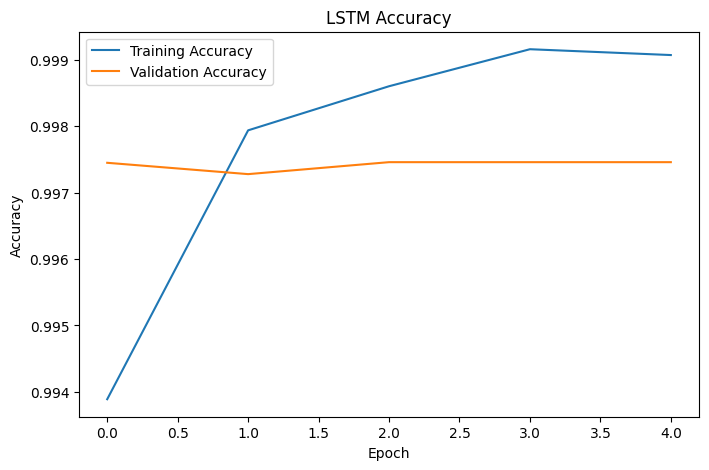

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

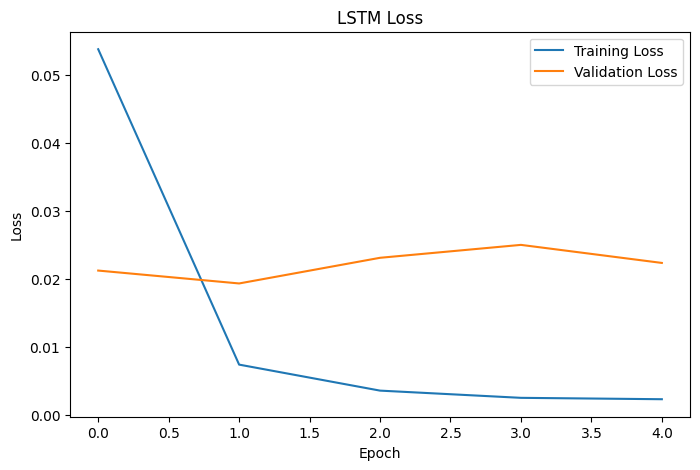

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Test Evaluation

In [17]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

1497/1497 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9980 - loss: 0.0110
Test Loss: 0.0110
Test Accuracy: 0.9980


In [18]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

1497/1497 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step


# Classification Report

In [19]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Anomaly"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     46410
     Anomaly       0.94      1.00      0.97      1474

    accuracy                           1.00     47884
   macro avg       0.97      1.00      0.98     47884
weighted avg       1.00      1.00      1.00     47884



# Confusion Matrix

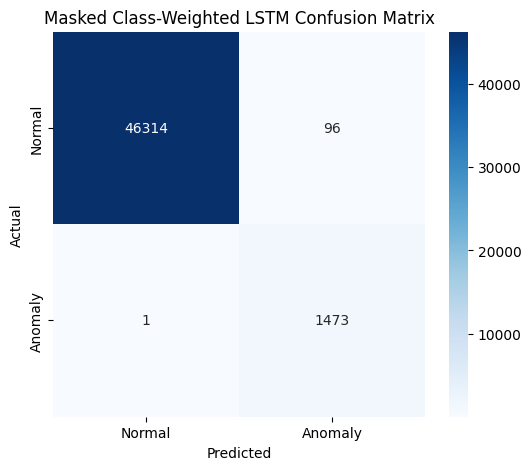

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Anomaly"],
    yticklabels=["Normal", "Anomaly"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Masked Class-Weighted LSTM Confusion Matrix")
plt.show()

# ROC-AUC and PR-AUC

In [21]:
roc_auc = roc_auc_score(y_test, y_pred_prob)
pr_auc = average_precision_score(y_test, y_pred_prob)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

ROC-AUC: 0.9996
PR-AUC: 0.9821


In [22]:
final_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Anomaly Precision": precision_score(y_test, y_pred, zero_division=0),
    "Anomaly Recall": recall_score(y_test, y_pred, zero_division=0),
    "Anomaly F1": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
}

for metric, value in final_results.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.9980
Anomaly Precision: 0.9388
Anomaly Recall: 0.9993
Anomaly F1: 0.9681
ROC-AUC: 0.9996
PR-AUC: 0.9821


# Save Model

In [23]:
model.save("HDFS_Masked_ClassWeighted_LSTM.keras")
print("Model saved successfully.")

Model saved successfully.
